## 1. Librerías y cargado del dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, RocCurveDisplay)

from google.colab import drive

# Se carga el dataset
drive.mount('/content/drive')

path  = '/content/drive/MyDrive/TFM/data/cleaned_dataset.csv'
df = pd.read_csv(path ,encoding='Latin-1')

Mounted at /content/drive


## 2. Exploración inicial del dataset

In [3]:
# Dimensiones, nulos y tipos
print("Dimensiones:", df.shape)
print(df.info())
print(df["DIABETE3"].value_counts(normalize=True))

Dimensiones: (257709, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257709 entries, 0 to 257708
Data columns (total 23 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   GENHLTH   257709 non-null  float64
 1   BPHIGH4   257709 non-null  float64
 2   BPMEDS    257709 non-null  float64
 3   BLOODCHO  257709 non-null  float64
 4   HAVARTH3  257709 non-null  float64
 5   ADDEPEV2  257709 non-null  float64
 6   DIABETE3  257709 non-null  float64
 7   SEX       257709 non-null  float64
 8   QLACTLM2  257709 non-null  float64
 9   USEEQUIP  257709 non-null  float64
 10  BLIND     257709 non-null  float64
 11  DECIDE    257709 non-null  float64
 12  DIFFWALK  257709 non-null  float64
 13  DIFFDRES  257709 non-null  float64
 14  DIFFALON  257709 non-null  float64
 15  SMOKE100  257709 non-null  float64
 16  EXEROFT1  257709 non-null  float64
 17  _RACE     257709 non-null  float64
 18  _AGEG5YR  257709 non-null  float64
 19  _BMI5CAT  257709 n

In [4]:
# Se normaliza el target
df["DIABETE3"] = df["DIABETE3"].map({1.0: 1, 3.0: 0})
df["DIABETE3"].value_counts()

,count
DIABETE3,
0,229318
1,28391


/tmp/ipython-input-4029100069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="DIABETE3", palette="Set2")


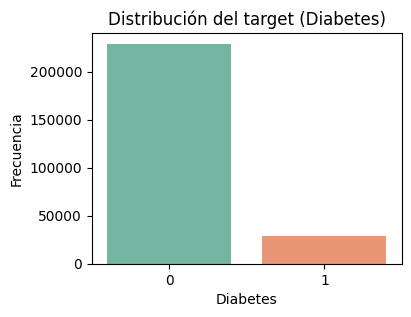

In [5]:
# Distribución del target
plt.figure(figsize=(4,3))
sns.countplot(data=df, x="DIABETE3", palette="Set2")
plt.title("Distribución del target (Diabetes)")
plt.xlabel("Diabetes")
plt.ylabel("Frecuencia")
plt.show()

## 3. Análisis Exploratorio de Datos (EDA)

In [6]:
# Se definen las categorías de variables
categorical_nominal = [
    'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'HAVARTH3', 'QLACTLM2',
    'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES',
    'DIFFALON', 'SMOKE100', 'ADDEPEV2', '_RACE', 'SEX'
]
categorical_ordinal = ['GENHLTH', '_PACAT1', '_AGEG5YR', '_BMI5CAT']
numeric_vars = ['EXEROFT1', '_FRUTSUM', '_VEGESUM']
target = "DIABETE3"

### 3.1. Variables categóricas nominales

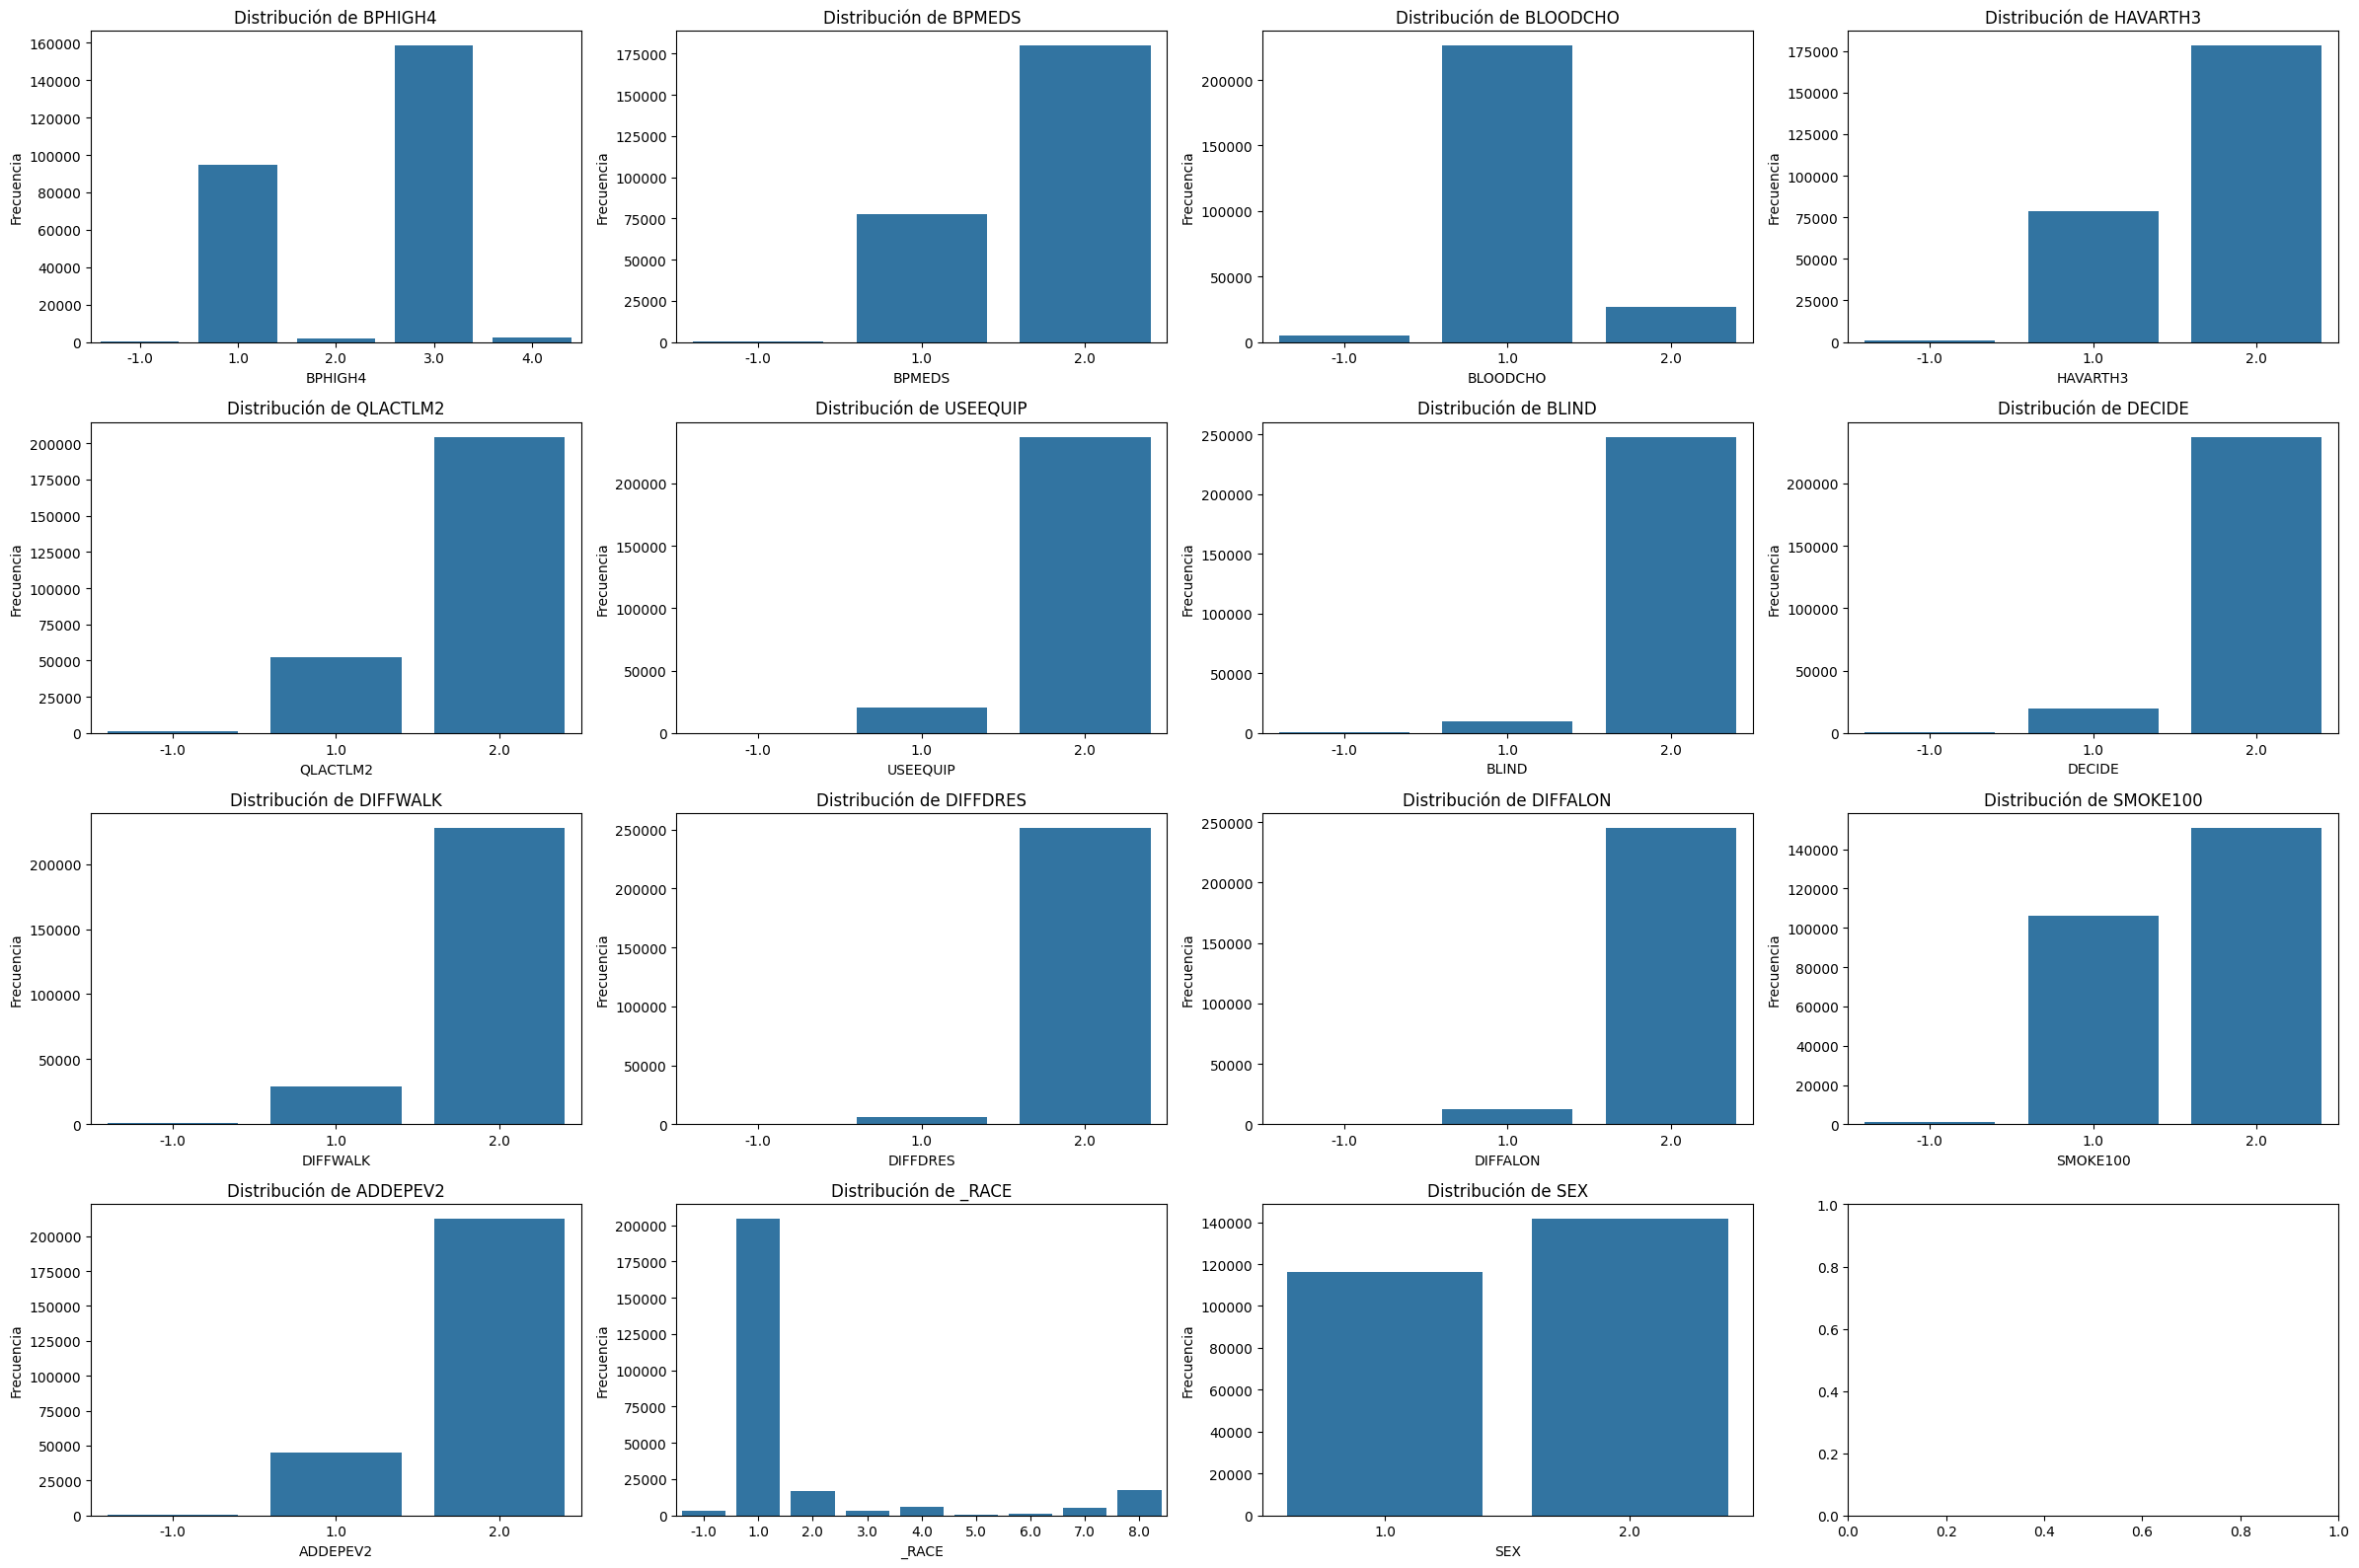

In [7]:
# Distribución entre clases
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_nominal):
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


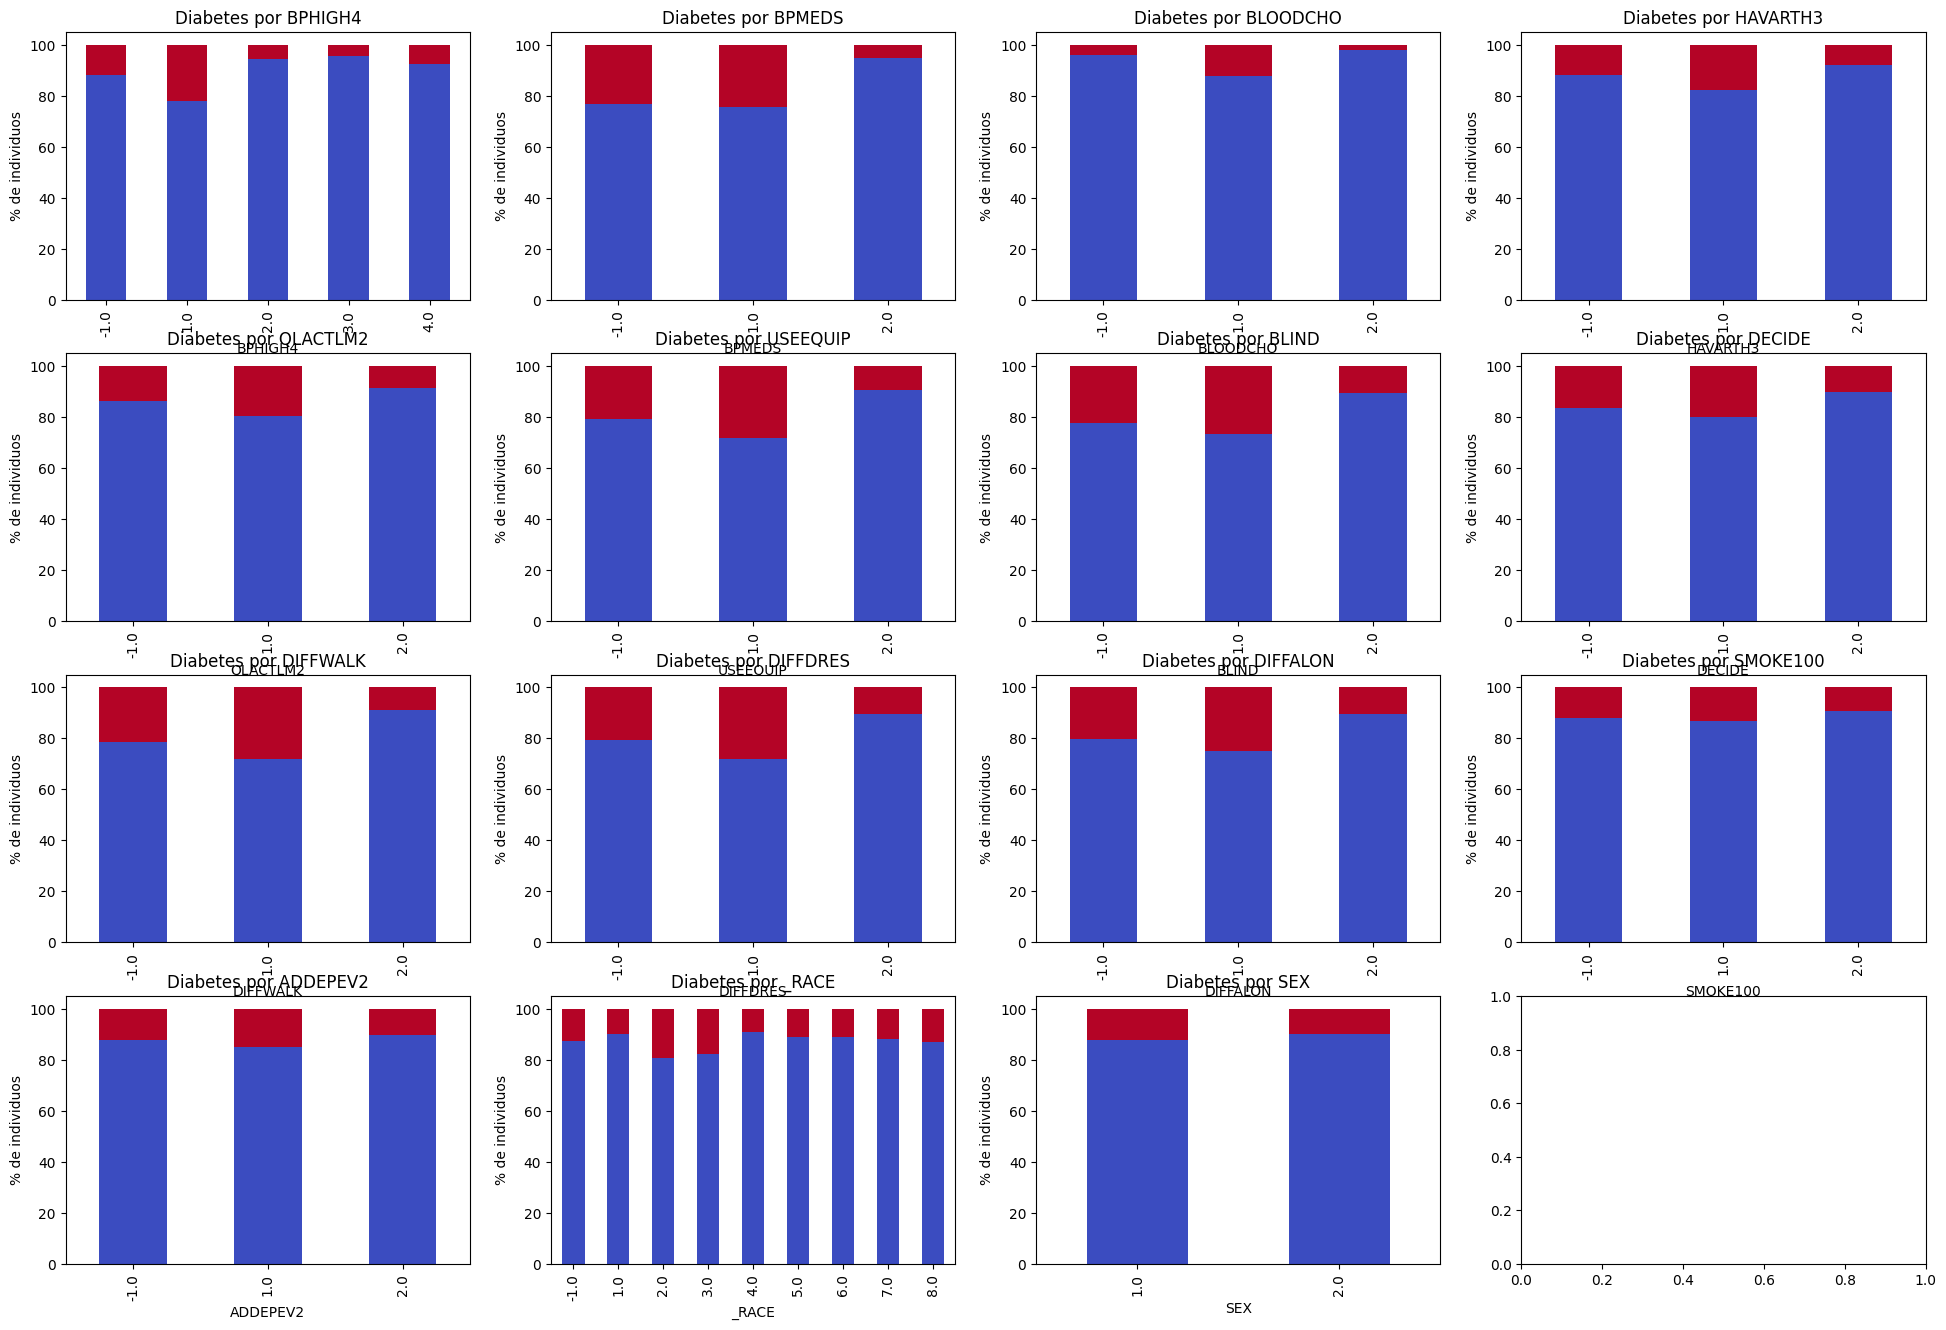

In [8]:
# Distribución del target en función de las clases
fig, axes = plt.subplots(4, 4, figsize=(24, 16))
axes = axes.flatten()
for i, col in enumerate(categorical_nominal):
    prop = pd.crosstab(df[col], df[target], normalize='index') * 100
    prop.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(f"Diabetes por {col}")
    axes[i].set_ylabel("% de individuos")
    axes[i].set_xlabel(col)

### 3.2. Variables categóricas ordinales

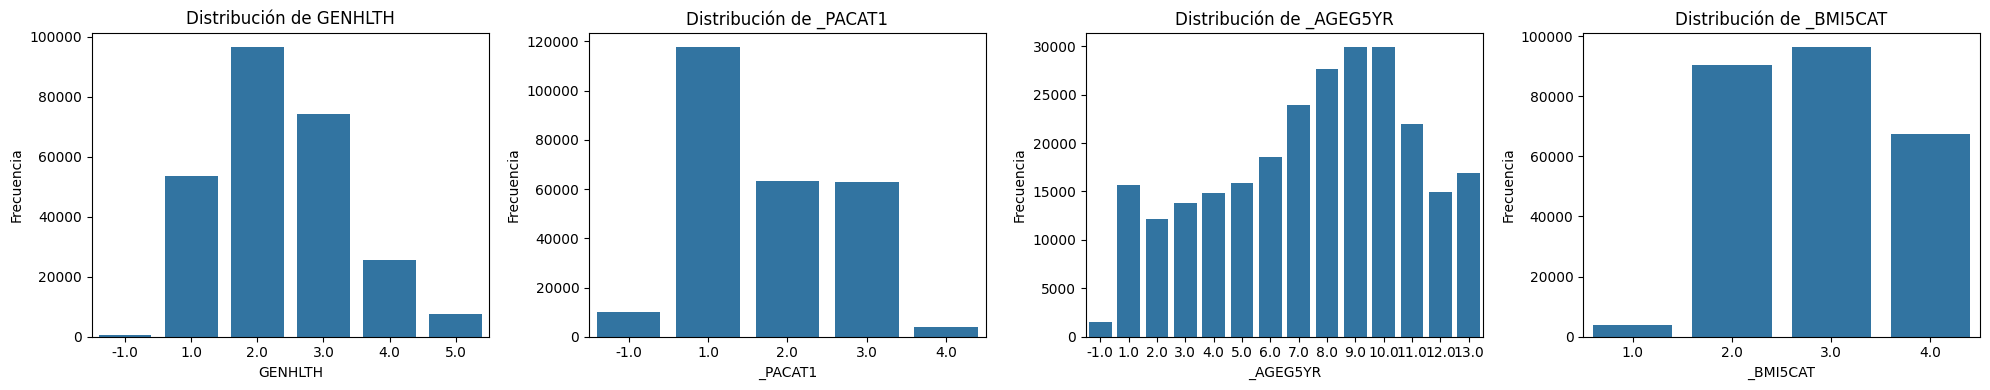

In [9]:
# Distribución entre clases
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(categorical_ordinal):
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

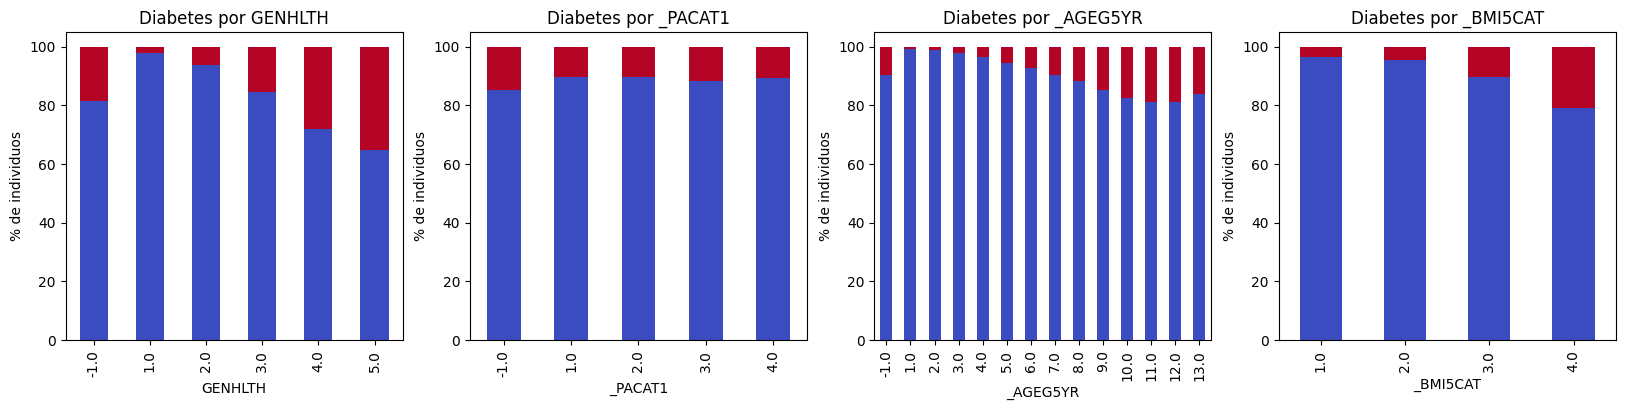

In [10]:
# Distribución del target en función de las clases
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(categorical_ordinal):
    prop = pd.crosstab(df[col], df[target], normalize='index') * 100
    prop.plot(kind='bar', stacked=True, colormap='coolwarm', ax=axes[i], legend=False)
    axes[i].set_title(f"Diabetes por {col}")
    axes[i].set_ylabel("% de individuos")
    axes[i].set_xlabel(col)

### 3.3. Variables numéricas

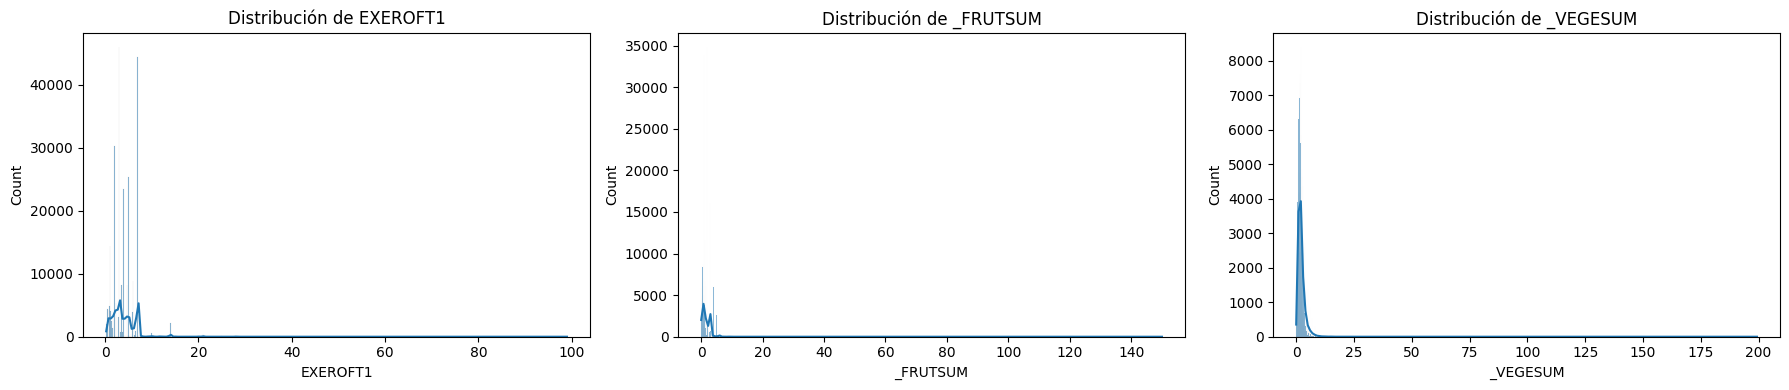

In [11]:
# Histogramas
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(numeric_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

/tmp/ipython-input-689700411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, ax=axes[i], palette="coolwarm")
/tmp/ipython-input-689700411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, ax=axes[i], palette="coolwarm")
/tmp/ipython-input-689700411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target, y=col, data=df, ax=axes[i], palette="coolwarm")


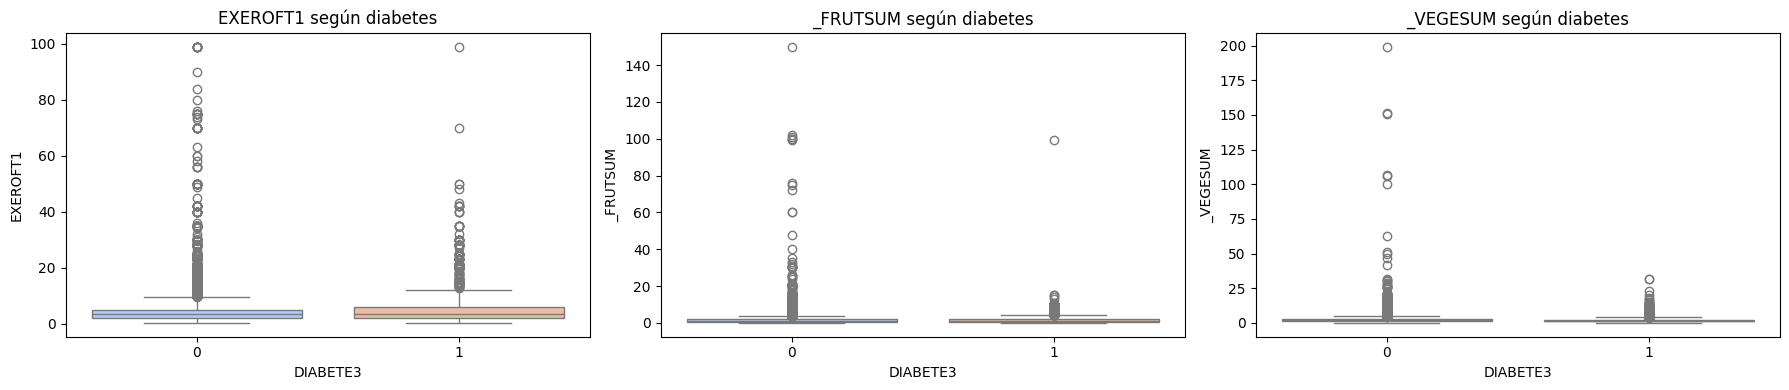

In [12]:
# Boxplots por estado de diabetes
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(numeric_vars):
    sns.boxplot(x=target, y=col, data=df, ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"{col} según diabetes")
plt.tight_layout()
plt.show()

In [32]:
# En producción, los valores de entrada se acotarán usando límites estadísticos del dataset para evitar valores fuera de distribución
def boxplot_stats(df, col):
    x = df[col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    return {
        "lower_fence": q1 - 1.5 * iqr,
        "upper_fence": q3 + 1.5 * iqr,
    }
print(boxplot_stats(df, 'EXEROFT1'))
print(boxplot_stats(df, '_FRUTSUM'))
print(boxplot_stats(df, '_VEGESUM'))

{'lower_fence': np.float64(-2.5), 'upper_fence': np.float64(9.5)}
{'lower_fence': np.float64(-1.3250000000000002), 'upper_fence': np.float64(3.995)}
{'lower_fence': np.float64(-0.8549999999999998), 'upper_fence': np.float64(4.625)}


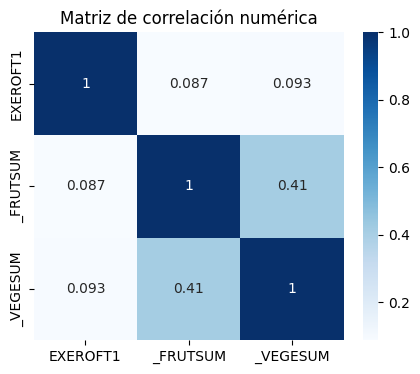

In [14]:
# Matriz de correlación
corr = df[numeric_vars].corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Matriz de correlación numérica")
plt.show()

### 3.4. Correlaciones (numéricas + ordinales + target)

In [15]:
def eda_correlations(df, numeric_vars, categorical_ordinal, target):
    print("\n=========== MATRIZ DE CORRELACIONES ===========\n")

    corr_vars = numeric_vars + categorical_ordinal

    corr_df = df[corr_vars].copy()
    corr_df[target] = df[target]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlaciones numéricas + ordinales + target")
    plt.tight_layout()
    plt.show()


=========== MATRIZ DE CORRELACIONES ===========



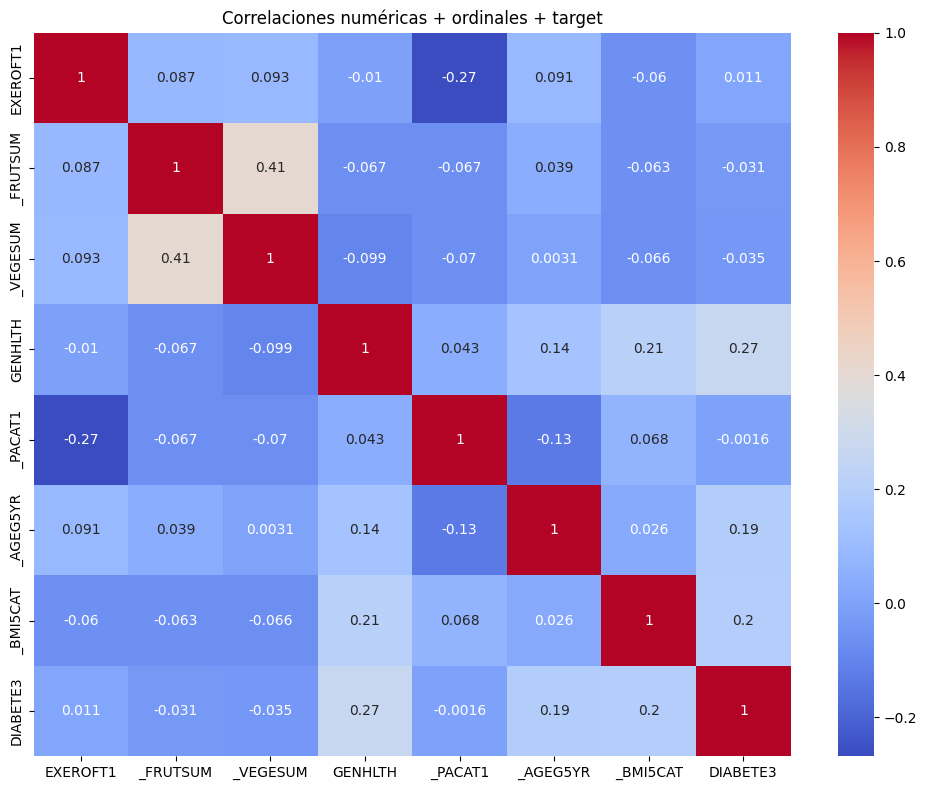

In [16]:
eda_correlations(df, numeric_vars, categorical_ordinal, target)

## 4. División del dataset

In [17]:
# Se divide en entrenamiento (60%), validación (20%) y test (20%).
X = df.drop(target, axis=1)
y = df[target]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (154625, 22), Val: (51542, 22), Test: (51542, 22)


## 5. Pipelines de preprocesamiento

In [18]:
# Categóricas nominales: Most frequent y OneHot
nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [19]:
# Categóricas ordinales: Most frequent (ya está codificadas las clases correctamente)
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

In [20]:
# Numéricas: KNN Imputer y StandardScaler
numeric_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),   # Se capturan relaciones no lineales
    ('scaler', StandardScaler())
])

In [21]:
# ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('nom', nominal_pipeline, categorical_nominal),
    ('ord', ordinal_pipeline, categorical_ordinal),
    ('num', numeric_pipeline, numeric_vars),
])

## 6. Definición de modelos base

In [22]:
# Pipelines finales
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced', random_state=42))
    ]),
    'Decision Tree Classifier': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=12, min_samples_split=350, class_weight='balanced', random_state=42))
    ]),
    'Gaussian Naive Bayes': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB())
    ])
}

## 7. Entrenamiento y evaluación

In [23]:
# Threshold para convertir probabilidades en clases binarias
threshold = 0.25

# Listas para almacenar resultados de métricas
results_val = []
results_test = []

### 7.1. Iteración sobre los modelos

In [24]:
# Se entrena cada modelo y se calculan las métricas de evaluación para validación y test.
for idx, (name, pipe) in enumerate(models.items()):

    # Entrenamiento del modelo
    pipe.fit(X_train, y_train)

    # Evaluación en el conjunto de Validación
    y_prob_val = pipe.predict_proba(X_val)[:, 1]
    y_pred_val = (y_prob_val >= threshold).astype(int)

    precision_val, recall_vals_val, _ = precision_recall_curve(y_val, y_prob_val)
    results_val.append({
        'Model': name,
        'Recall': recall_score(y_val, y_pred_val),
        'F1-score': f1_score(y_val, y_pred_val),
        'ROC-AUC': roc_auc_score(y_val, y_prob_val),
        'PR-AUC': auc(recall_vals_val, precision_val)
    })

    # Evaluación en el conjunto de Test
    y_prob_test = pipe.predict_proba(X_test)[:, 1]
    y_pred_test = (y_prob_test >= threshold).astype(int)

    precision_test, recall_vals_test, _ = precision_recall_curve(y_test, y_prob_test)
    results_test.append({
        'Model': name,
        'Recall': recall_score(y_test, y_pred_test),
        'F1-score': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_prob_test),
        'PR-AUC': auc(recall_vals_test, precision_test)
    })

### 7.2. Matrices de confusión

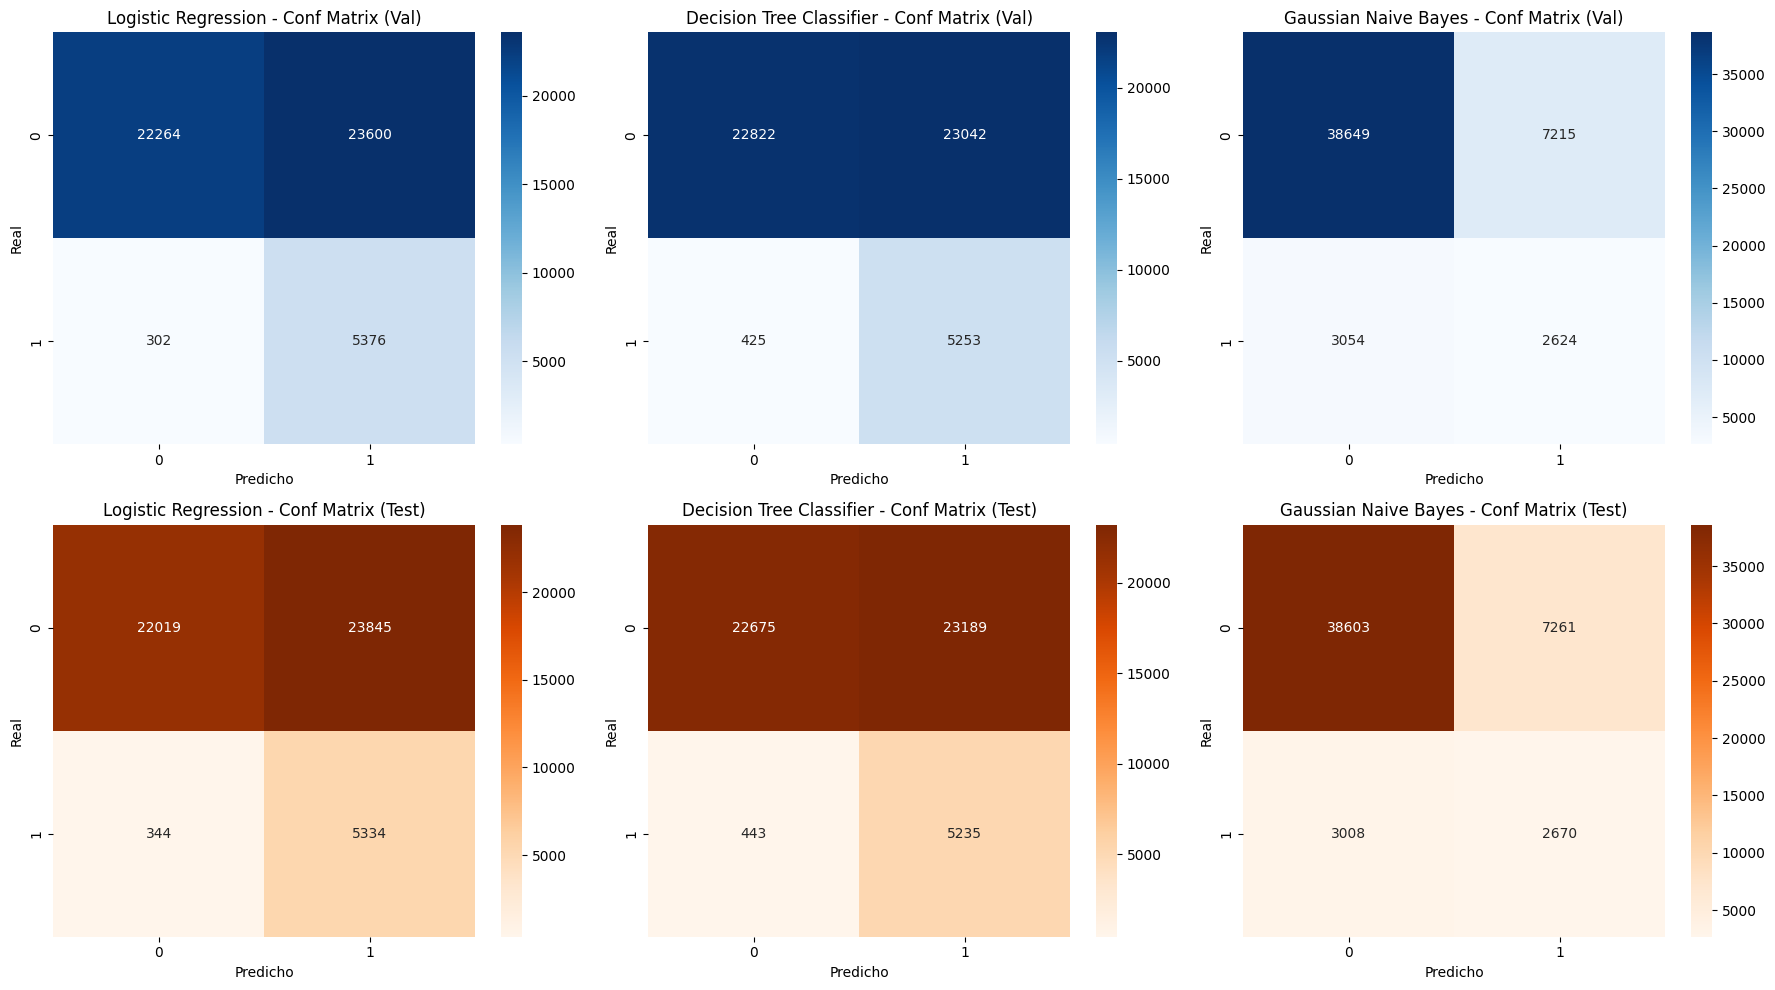

In [25]:
# Se crea una figura para matrices de confusión: 2 filas (Val/Test) x 3 columnas (modelos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, pipe) in enumerate(models.items()):
    # Validación
    cm_val = confusion_matrix(y_val, (pipe.predict_proba(X_val)[:,1] >= threshold).astype(int))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1], ax=axes[0, idx])
    axes[0, idx].set_title(f'{name} - Conf Matrix (Val)')
    axes[0, idx].set_xlabel('Predicho')
    axes[0, idx].set_ylabel('Real')

    # Test
    cm_test = confusion_matrix(y_test, (pipe.predict_proba(X_test)[:,1] >= threshold).astype(int))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', xticklabels=[0,1], yticklabels=[0,1], ax=axes[1, idx])
    axes[1, idx].set_title(f'{name} - Conf Matrix (Test)')
    axes[1, idx].set_xlabel('Predicho')
    axes[1, idx].set_ylabel('Real')

plt.tight_layout()
plt.show()

### 7.3. Curvas ROC (RocCurveDisplay)

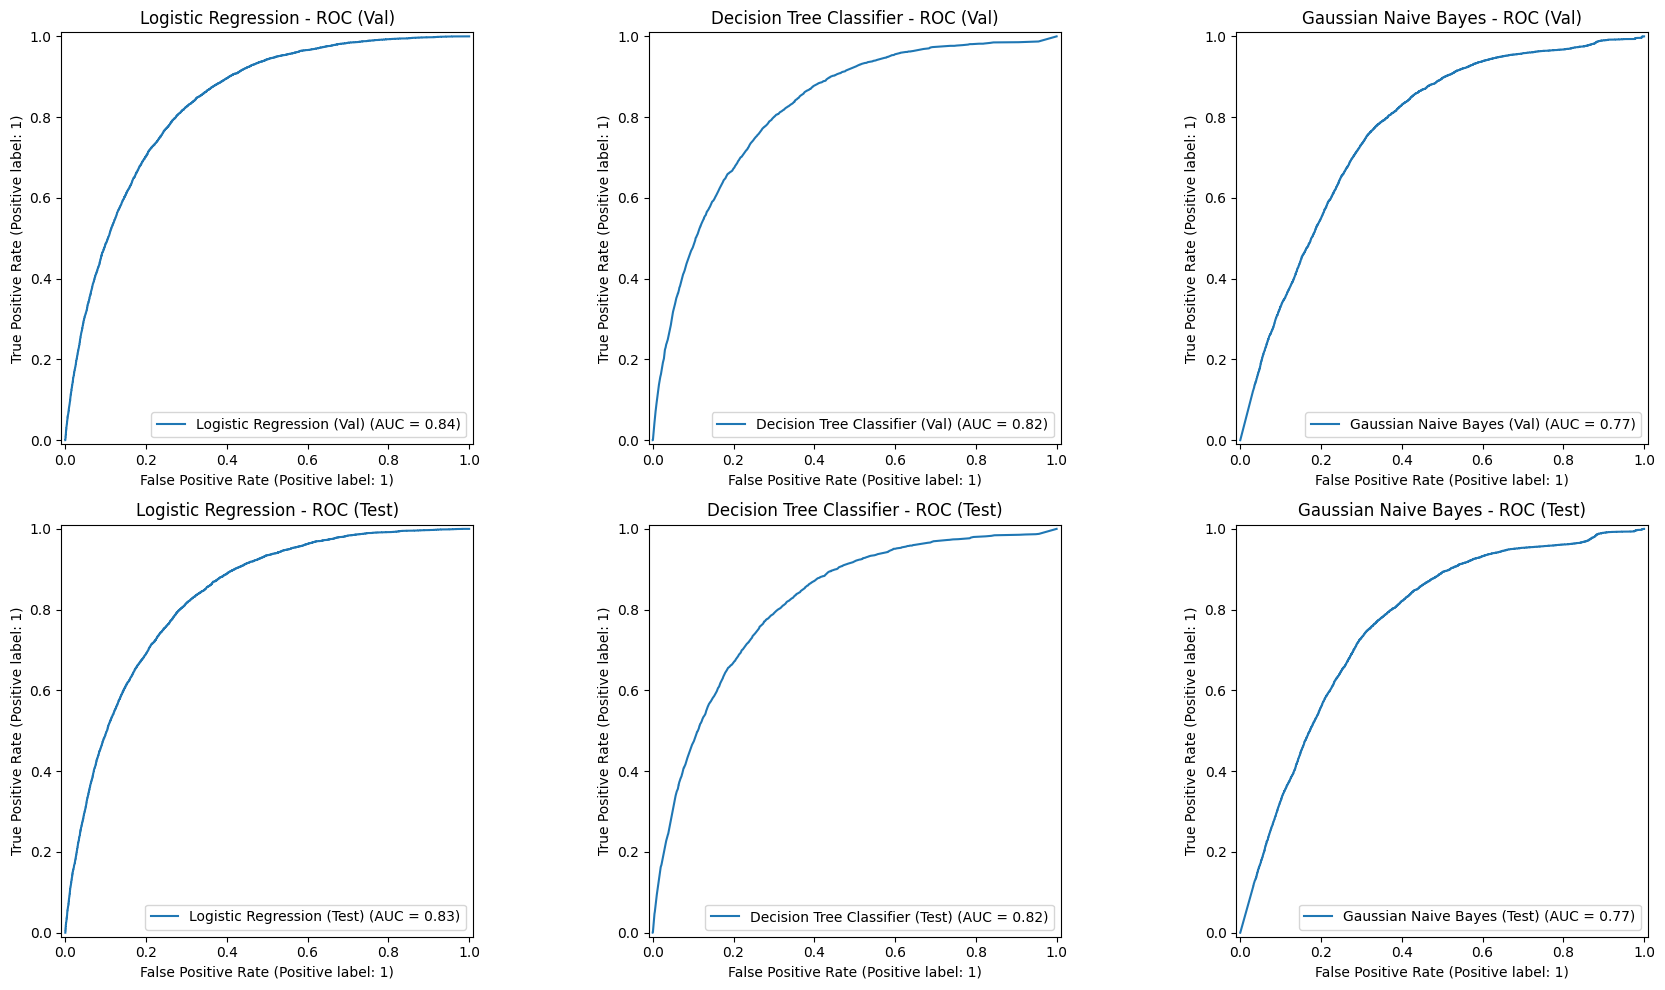

In [26]:
# Se crea una figura para curvas ROC: 2 filas (Val/Test) x 3 columnas (modelos)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, pipe) in enumerate(models.items()):

    # Validación
    y_prob_val = pipe.predict_proba(X_val)[:,1]
    RocCurveDisplay.from_predictions(y_val, y_prob_val, name=f"{name} (Val)", ax=axes[0, idx])
    axes[0, idx].set_title(f'{name} - ROC (Val)')

    # Test
    y_prob_test = pipe.predict_proba(X_test)[:,1]
    RocCurveDisplay.from_predictions(y_test, y_prob_test, name=f"{name} (Test)", ax=axes[1, idx])
    axes[1, idx].set_title(f'{name} - ROC (Test)')

plt.tight_layout()
plt.show()

### 7.4 Resultados finales

In [27]:
df_results_val = pd.DataFrame(results_val)
df_results_test = pd.DataFrame(results_test)

print("=== VALIDATION SET ===")
display(df_results_val)

print("=== TEST SET ===")
display(df_results_test)

=== VALIDATION SET ===


,Model,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.946812,0.310267,0.836499,0.369496
1,Decision Tree Classifier,0.925150,0.309246,0.822376,0.362911
2,Gaussian Naive Bayes,0.462135,0.338210,0.772267,0.295854


=== TEST SET ===


,Model,Recall,F1-score,ROC-AUC,PR-AUC
0,Logistic Regression,0.939415,0.30605,0.832867,0.370277
1,Decision Tree Classifier,0.921980,0.30702,0.817638,0.357628
2,Gaussian Naive Bayes,0.470236,0.34211,0.767990,0.291184


### 7.5. Importancia de variables

In [28]:
# Cálculo de importancia
# Se crea un diccionario vacío donde se almacenará la importancia de las variables para cada modelo
importancias_modelos = {}

for name, pipe in models.items():
    # Se extrae el modelo final
    modelo_final = pipe.named_steps['classifier']

    # Se extraen los nombres de features después del preprocesador
    preprocessor = pipe.named_steps['preprocessor']
    feature_names = []

    # Numéricas, no se expanden ni transforman en cantidad de columnas
    feature_names.extend(numeric_vars)

    # Nominales (OneHotEncoder expande columnas, generando una columna por clase)
    nominal_ohe = preprocessor.named_transformers_['nom'].named_steps['onehot']
    # get_feature_names_out devuelve los nombres de nuevas columnas, alineando las importancias de los modelos con los nombres reales de las columnas
    nominal_features = nominal_ohe.get_feature_names_out(categorical_nominal)
    feature_names.extend(nominal_features)

    # Ordinales, ya estaban codificadas, no fue necesario expandirlas
    feature_names.extend(categorical_ordinal)

    # Se calcula la importancia según el tipo de modelo
    if hasattr(modelo_final, 'feature_importances_'):  # DecisionTree
        importances = modelo_final.feature_importances_
    elif hasattr(modelo_final, 'coef_'):  # LogisticRegression
        importances = np.abs(modelo_final.coef_[0])
    elif hasattr(modelo_final, 'theta_'):  # GaussianNB
        # Diferencia entre medias por clase como proxy (aproximación)
        importances = np.abs(modelo_final.theta_[1] - modelo_final.theta_[0])
    else:
        importances = None

    if importances is not None and len(importances) == len(feature_names):
        df_importance = pd.DataFrame({
            'Variable': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)
        importancias_modelos[name] = df_importance

# Mostrar top 10 variables para cada modelo
if importancias_modelos:
    for modelo, df_imp in importancias_modelos.items():
        print(f"\nTop 10 variables más importantes para {modelo}:")
        print(df_imp.head(10).to_string(index=False))
else:
    print("No hay importancias para mostrar. Se verifica que los modelos tengan atributos válidos y que el diccionario se llenó correctamente.")


Top 10 variables más importantes para Logistic Regression:
     Variable  Importance
  BPHIGH4_4.0    0.922222
   BPMEDS_2.0    0.751375
      GENHLTH    0.632972
    _RACE_8.0    0.616187
    _RACE_7.0    0.546191
 USEEQUIP_2.0    0.515510
DIFFWALK_-1.0    0.470353
 ADDEPEV2_1.0    0.464099
BLOODCHO_-1.0    0.462215
HAVARTH3_-1.0    0.404199

Top 10 variables más importantes para Decision Tree Classifier:
    Variable  Importance
 BPHIGH4_4.0    0.459354
   _RACE_8.0    0.233536
     SEX_2.0    0.108608
     GENHLTH    0.074031
    _BMI5CAT    0.023930
    _AGEG5YR    0.017810
  BPMEDS_1.0    0.013730
ADDEPEV2_1.0    0.010718
     _PACAT1    0.009806
   _RACE_6.0    0.007555

Top 10 variables más importantes para Gaussian Naive Bayes:
    Variable  Importance
     SEX_2.0    2.097295
   _RACE_8.0    0.874060
     GENHLTH    0.508927
 BPHIGH4_4.0    0.419032
 BPHIGH4_3.0    0.418272
    _FRUTSUM    0.408862
BPHIGH4_-1.0    0.401972
BLOODCHO_2.0    0.210653
BLOODCHO_1.0    0.210433
  D